In [53]:
import pandas as pd
import scipy as sp
import numpy as np
from matplotlib import pyplot as plt

The columns that I used below are, V241458x (age of voter on election day), V242067 (who the person voted for), V240002c (Pre/Post Interview Completion Status) to get data on those who filled out the information after the election, and V240108b (sampling weights per row) is needed to perform the statistical tests seen later on.

The Goal of this analysis is to undestand the relationship between the age of the voter and their vote choice, so we can see if there is a correlation between the two continuous variables.

In [54]:
anes2024_csv = "../../../dataset/data_2024/anes_timeseries_2024_csv_20250808.csv"
df = pd.read_csv(anes2024_csv)
df_useful = df[["V241458x", "V242067", "V240002c", "V240108b"]]
df_useful

C:\Users\shast\AppData\Local\Temp\ipykernel_26844\3773667444.py:2: DtypeWarning: Columns (0: V240101a, 1: V240101c, 2: V240101d, 3: V240103a, 4: V240103c, 5: V240103d, 6: V240104a, 7: V240104c, 8: V240104d, 9: V240105a, 10: V240105c, 11: V240105d, 12: V240106a, 13: V240106c, 14: V240106d, 15: V240108a, 16: V240108c, 17: V240108d, 18: V243002, 19: V243003, 20: V243004, 21: V243005, 22: V243006, 23: V243009, 24: V243050, 25: V243051, 26: V243052, 27: V243053, 28: V243056, 29: V243057, 30: V243058) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(anes2024_csv)


,V241458x,V242067,V240002c,V240108b
0,50,2,2,.780974621163524
1,41,-1,2,2.50707498962934
2,44,1,2,.814400897948447
3,45,-1,2,.263490124186044
4,80,2,2,.216673241876399
...,...,...,...,...
5516,-2,-6,1,
5517,69,1,2,1.90730910362323
5518,-2,-6,1,
5519,28,1,2,2.56436072555069


In [55]:
# Changed the names of each of the columns 

df_select = df[["V241458x", "V242067", "V240002c", "V240108b"]]

df_select = df_select.rename(columns={
    "V241458x": "Age",
    "V242067": "President Vote",
    "V240002c": "Completed Post Survey",
    "V240108b": "Weights"
})

df_select

,Age,President Vote,Completed Post Survey,Weights
0,50,2,2,.780974621163524
1,41,-1,2,2.50707498962934
2,44,1,2,.814400897948447
3,45,-1,2,.263490124186044
4,80,2,2,.216673241876399
...,...,...,...,...
5516,-2,-6,1,
5517,69,1,2,1.90730910362323
5518,-2,-6,1,
5519,28,1,2,2.56436072555069


In [56]:
# changed the numbers that represent each "President Vote" to the name of said president 

president_dict = { # V242067
    -9: "Refused",
    -1: "Inapplicable",
    1: "Harris", #"Kamala Harris",
    2: "Trump", #"Donald Trump",
    3: "RFK Jr.", #"Robert F. Kennedy, Jr.",
    4: "West", #"Cornel West",
    5: "Stein", #"Jill Stein",
    6: "Other", #"Another candidate {SPECIFY}"
}
df_select["President Vote"] = df["V242067"].map(president_dict)

# empty weight values represented as 0
df_select["Weights"] = df_select["Weights"].apply(lambda x: 0 if x == ' ' or x == '' else x)
df_select["Weights"] = df_select["Weights"].astype(float)

# remove ages below 18 years old
df_select = df_select[df_select["Age"] >= 18]

df_select

,Age,President Vote,Completed Post Survey,Weights
0,50,Trump,2,0.780975
1,41,Inapplicable,2,2.507075
2,44,Harris,2,0.814401
3,45,Inapplicable,2,0.263490
4,80,Trump,2,0.216673
...,...,...,...,...
5514,42,Inapplicable,2,0.596674
5515,80,Harris,2,0.094869
5517,69,Harris,2,1.907309
5519,28,Harris,2,2.564361


In [62]:
# drop missing values 
df_select = df_select.dropna()

# only keep data points where people finished the post survey
df_select = df_select[df_select["Completed Post Survey"] == 2]

# remove inapplicable or refused rows of people who didn't pick a candidate
df_select = df_select[df_select["President Vote"].isin(["Harris", "Trump", "West", "Stein", "Other"])]

df_select

,Age,President Vote,Completed Post Survey,Weights
0,50,Trump,2,0.780975
2,44,Harris,2,0.814401
4,80,Trump,2,0.216673
6,41,Trump,2,0.292916
10,59,Harris,2,0.964122
...,...,...,...,...
5507,45,Other,2,3.252915
5515,80,Harris,2,0.094869
5517,69,Harris,2,1.907309
5519,28,Harris,2,2.564361


EDA

First we examine the basic characteristics of the age variable across the dataset, by looking at the mean, median, standard deviation, and distribution for each candiate. 

In [63]:
print("Age Data Statistics: ")
print("----------------------")
print(df_select["Age"].describe())

Age Data Statistics: 
----------------------
count    3531.000000
mean       55.174172
std        16.769812
min        18.000000
25%        41.000000
50%        57.000000
75%        69.000000
max        80.000000
Name: Age, dtype: float64


In [64]:
print("Mean Age by Candidate: ")
print("-------------------------")
print(df_select.groupby("President Vote")["Age"].mean())

Mean Age by Candidate: 
-------------------------
President Vote
Harris    54.862300
Other     45.576923
Stein     46.090909
Trump     56.124668
West      42.200000
Name: Age, dtype: float64


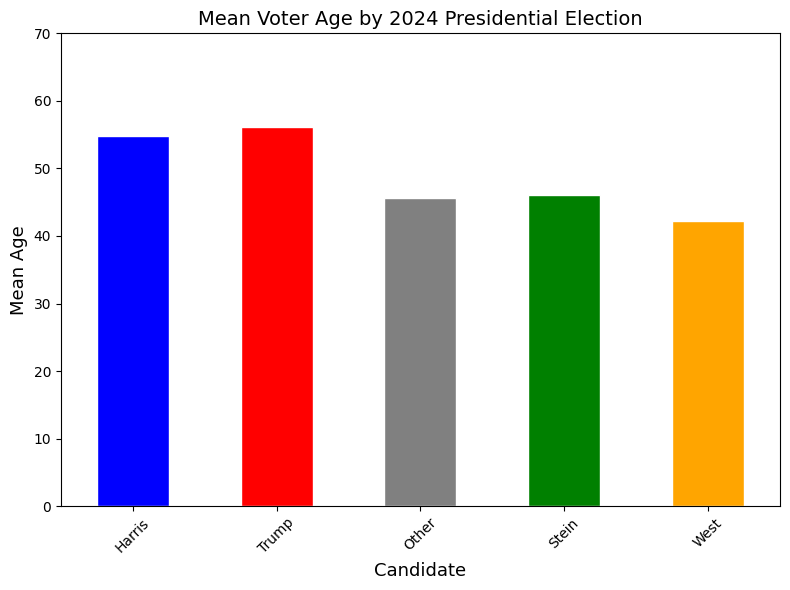

In [67]:
# A bar chart to showcase the relationship between age and candiate selection

fig, ax = plt.subplots(figsize=(8, 6))

mean_ages = df_select.groupby("President Vote")["Age"].mean().reindex(["Harris", "Trump", "Other", "Stein", "West"])

mean_ages.plot.bar(color=["blue", "red", "gray", "green", "orange", "purple"],  edgecolor="white", ax=ax, width=0.5)

ax.set_xlabel("Candidate", fontsize=13)
ax.set_ylabel("Mean Age", fontsize=13)
ax.set_title("Mean Voter Age by 2024 Presidential Election", fontsize=14)
ax.set_ylim(0, 70)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Now to better see the distribution of the ages of each candidate the variance of the data we can use a side by side boxplot.
This will allow us to exclude large or too small values which might skew the reslts

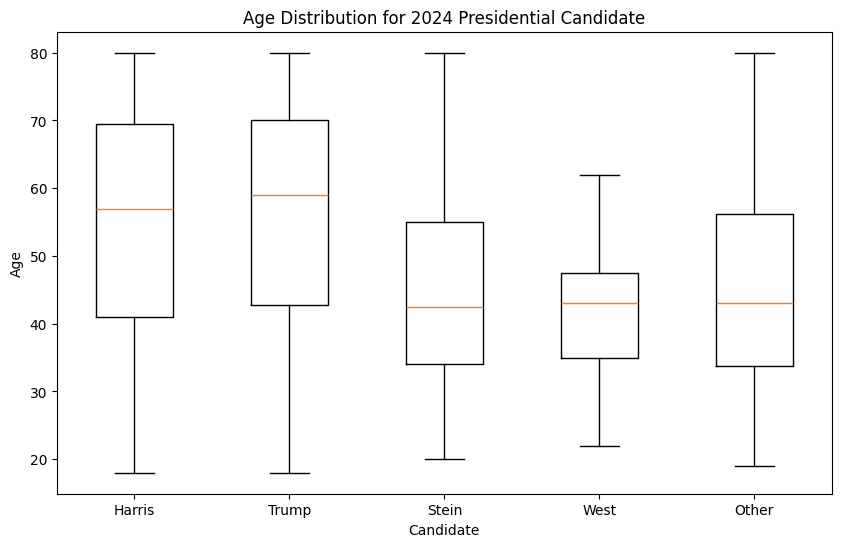

In [68]:
# split the dataset for each candiate so we can make a box plot for each one, for a side by side comparison
df_harris = df_select[df_select["President Vote"] == "Harris"]
df_trump = df_select[df_select["President Vote"] == "Trump"]
df_stein = df_select[df_select["President Vote"] == "Stein"]
df_west = df_select[df_select["President Vote"] == "West"]
df_other = df_select[df_select["President Vote"] == "Other"]

plt.figure(figsize=(10, 6))
plt.boxplot([df_harris["Age"], df_trump["Age"], df_stein["Age"], df_west["Age"], df_other["Age"]],
            tick_labels=["Harris", "Trump", "Stein", "West", "Other"])
plt.ylabel("Age")
plt.xlabel("Candidate")
plt.title("Age Distribution for 2024 Presidential Candidate")
plt.show()

Now we will do Kruskal-Wallis Hypothesis Test

H_0 (null hypothesis): The age distributions of all candidates are the same, so there is no difference in the age of who voted for each candidate.

H_1 (alternative hypothesis): At least one candidate has a significantly different age distribution than the others. 

In [72]:
stat, p_value = sp.stats.kruskal(df_harris["Age"], df_trump["Age"],  df_stein["Age"], df_west["Age"], df_other["Age"])
print(f"Kruskal-Wallis H statistic: {stat:.4f}")
print(f"P-value: {p_value:.2e}")

Kruskal-Wallis H statistic: 33.4709
P-value: 9.57e-07


In [73]:
# we will use p = 0.05 to determine whether to reject or fail to reject the null
if p_value < 0.05:
    print("Reject null hypothesis -  At least one candidate has a significantly different age distribution than the others")
else: 
    print("Fail to reject null - The age distributions of all candidates are the same")
    

Reject null hypothesis -  At least one candidate has a significantly different age distribution than the others


From this data exploration, we can see several patterns in the 
relationship between respondent age and their candidate choice.

First the descriptive stats reveal that Trump voters have the highest mean age 
at 56.1 years, followed by Harris voters at 54.9 years. Third party candidates 
tend to attract younger voters, with West voters averaging 42.2 years and Stein 
voters at 46.1 years. The overall sample has a mean age of 55.2 years, suggesting 
the dataset skews older.

The boxplots further support this trend, showing that Trump voters have the highest 
median age, followed closely by Harris voters. Third party candidates attract 
noticeably younger voters with lower medians. 

The Kruskal-Wallis test produced an H statistic of 33.47 and a p-value of 9.57e-07, 
which is far below the significance threshold of alpha = 0.05, we had chosen. We therefore 
reject the null hypothesis, that the age distributions across candidate groups are 
statistically significantly different and did not occur by chance.

Some issues to note are that third party candidates such as Stein, West, and 
Other have considerably smaller sample sizes compared to Harris and Trump, meaning 
conclusions drawn about those groups may not be as strong. Additionally, age is 
likely not the only factor influencing vote choice, as possible confounders include 
race, income, and party identification.

Nevertheless, the statistically significant result confirms that age is a 
meaningful variable in understanding 2024 presidential vote choice.